In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from pathlib import Path
from brainvision.constants import *

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def get_run_name(model_name: str, loss_name: str, strategy_or_fold: str):
    return f"{model_name.lower().replace('-','')}_{loss_name.lower()}_{strategy_or_fold}"


def plot_training_curves(history: dict, run_name: str = None):
    """
    Plot loss, F1, sensitivity, and specificity trends across training epochs.
    Expects history dict from train() with keys:
      train_loss, val_loss, val_f1, val_sens, val_spec, best_epoch
    """
    run_name = run_name or history.get('run_name', 'Run')
    epochs   = range(1, len(history['train_loss']) + 1)
    best_ep  = history['best_epoch']

    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    fig.suptitle(f"Training Curves — {run_name}", fontsize=14)

    # ── Loss ──────────────────────────────────────────────────────────────────
    ax = axes[0, 0]
    ax.plot(epochs, history['train_loss'], label='Train Loss', color='#378ADD')
    ax.plot(epochs, history['val_loss'],   label='Val Loss',   color='#D85A30')
    ax.axvline(best_ep, color='gray', linestyle='--', alpha=0.6, label=f'Best epoch ({best_ep})')
    ax.set_title("Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()

    # ── Macro F1 ──────────────────────────────────────────────────────────────
    ax = axes[0, 1]
    ax.plot(epochs, history['val_f1'], color='#5DCAA5')
    ax.axvline(best_ep, color='gray', linestyle='--', alpha=0.6)
    ax.scatter([best_ep], [history['best_f1']], color='#5DCAA5', zorder=5, s=60)
    ax.set_title(f"Validation Macro F1  (best={history['best_f1']:.4f})")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Macro F1")
    ax.set_ylim(0, 1)

    # ── Sensitivity ───────────────────────────────────────────────────────────
    ax = axes[1, 0]
    ax.plot(epochs, history['val_sens'], color='#7F77DD')
    ax.axvline(best_ep, color='gray', linestyle='--', alpha=0.6)
    if 'best_sens' in history:
        ax.scatter([best_ep], [history['best_sens']], color='#7F77DD', zorder=5, s=60)
    ax.set_title("Validation Sensitivity (Macro)")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Sensitivity")
    ax.set_ylim(0, 1)

    # ── Specificity ───────────────────────────────────────────────────────────
    ax = axes[1, 1]
    ax.plot(epochs, history['val_spec'], color='#EF9F27')
    ax.axvline(best_ep, color='gray', linestyle='--', alpha=0.6)
    if 'best_spec' in history:
        ax.scatter([best_ep], [history['best_spec']], color='#EF9F27', zorder=5, s=60)
    ax.set_title("Validation Specificity (Macro)")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Specificity")
    ax.set_ylim(0, 1)

    plt.tight_layout()
    plt.show()


def load_history(run_name: str) -> dict:
    """Load a saved training history from disk."""
    return np.load(f"{RESULTS_DIR}/{run_name}_history.npy", allow_pickle=True).item()

In [4]:
from brainvision.losses import CrossEntropyLoss, DiceLoss, FocalLoss, UnifiedFocalLoss
from brainvision.models import Baseline1DDNN, HuEtAl1DCNN, LeeEtAl2DCNN, HamidaEtAl3DCNN, HybridSN, SpectralFormer

MODEL_REGISTRY = {
    '1D-NN': lambda: Baseline1DDNN(
        input_channels  = N_DECIMATED_BANDS,
        n_classes       = N_CLASSES,
        dropout         = True,
        dropout_rate    = DROPOUT_RATE
    ),

    '1D-CNN': lambda: HuEtAl1DCNN(
        input_channels = N_DECIMATED_BANDS,
        n_classes      = N_CLASSES
    ),

    '2D-CNN': lambda: LeeEtAl2DCNN(
        input_channels = N_DECIMATED_BANDS,
        n_classes      = N_CLASSES,
        patch_size     = PATCH_SIZE
    ),

    '3D-CNN': lambda: HamidaEtAl3DCNN(
        input_channels = N_DECIMATED_BANDS,
        n_classes      = N_CLASSES,
        patch_size     = PATCH_SIZE
    ),
    
    'HybridSN': lambda: HybridSN(
        input_channels = N_DECIMATED_BANDS,
        n_classes      = N_CLASSES,
        patch_size     = PATCH_SIZE
    ),
    
    'SpectralFormer': lambda: SpectralFormer(
        input_channels = N_DECIMATED_BANDS,
        n_classes      = N_CLASSES,
        near_band      = SF_NEAR_BAND,
        dim            = SF_DIM,
        depth          = SF_DEPTH,
        heads          = SF_HEADS,
        dim_head       = SF_DIM_HEAD,
        mlp_dim        = SF_MLP_DIM,
        dropout        = SF_DROPOUT,
        emb_dropout    = SF_EMB_DROPOUT,
        mode           = SF_MODE,
    ),
}

PATCH_MODELS = {'2D-CNN', '3D-CNN', 'HybridSN'}

LOSS_REGISTRY = {
    'CE'  : lambda w: CrossEntropyLoss,
    'FL'  : lambda w: FocalLoss(alpha=w),
    'DL'  : lambda w: DiceLoss(),
    'UFL' : lambda w: UnifiedFocalLoss(alpha=w),
}

In [5]:
from brainvision.data import HSIPixelDataset, HSIPatchDataset


@torch.no_grad()
def predict(model, loader, device) -> tuple[np.ndarray, np.ndarray]:
    """Run inference, return (preds, targets) as numpy arrays."""
    model.eval()
    all_preds, all_targets = [], []
    for X, y in loader:
        X      = X.to(device)
        logits = model(X)
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_targets.extend(y.numpy())
    return np.array(all_preds), np.array(all_targets)


def compute_test_metrics(targets: np.ndarray,
                         preds:   np.ndarray,
                         run_name: str) -> dict:
    """
    Compute full test-set metrics:
      per-class Sensitivity, Specificity, Dice
      Macro F1, Overall Accuracy (OA)
    """
    n      = N_CLASSES
    labels = list(range(n))
    cm     = confusion_matrix(targets, preds, labels=labels)

    sensitivity = np.zeros(n)
    specificity = np.zeros(n)
    dice        = np.zeros(n)

    for i in range(n):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = cm.sum() - TP - FN - FP

        sensitivity[i] = TP / (TP + FN + 1e-6)
        specificity[i] = TN / (TN + FP + 1e-6)
        dice[i]        = (2 * TP) / (2 * TP + FP + FN + 1e-6)

    macro_f1 = f1_score(targets, preds, average='macro', zero_division=0)
    oa       = (preds == targets).mean()

    return {
        'run_name'         : run_name,
        'sensitivity'      : sensitivity,
        'specificity'      : specificity,
        'dice'             : dice,
        'macro_f1'         : macro_f1,
        'oa'               : oa,
        'confusion_matrix' : cm,
    }


def print_test_metrics(metrics: dict):
    """Pretty-print test metrics for one run."""
    print(f"\n{'═'*65}")
    print(f"  TEST RESULTS — {metrics['run_name']}")
    print(f"{'═'*65}")
    print(f"  Overall Accuracy (OA) : {metrics['oa']:.4f}")
    print(f"  Macro F1              : {metrics['macro_f1']:.4f}")
    print(f"\n  {'Class':<25} {'Sensitivity':>12} {'Specificity':>12} {'Dice':>8}")
    print(f"  {'─'*60}")
    for i in range(N_CLASSES):
        print(f"  {CLASS_NAMES[i+1]:<25} "
              f"{metrics['sensitivity'][i]:>12.4f} "
              f"{metrics['specificity'][i]:>12.4f} "
              f"{metrics['dice'][i]:>8.4f}")
    print(f"  {'─'*60}")
    print(f"  {'Mean':<25} "
          f"{metrics['sensitivity'].mean():>12.4f} "
          f"{metrics['specificity'].mean():>12.4f} "
          f"{metrics['dice'].mean():>8.4f}")


def plot_confusion_matrix(metrics: dict):
    """Plot row-normalised confusion matrix."""
    cm   = metrics['confusion_matrix']
    cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(
        confusion_matrix = cm_n,
        display_labels   = [CLASS_NAMES_SHORT[i+1] for i in range(N_CLASSES)]
    )
    disp.plot(ax=ax, colorbar=True, cmap='Blues', values_format='.2f')
    ax.set_title(f"Confusion Matrix — {metrics['run_name']}")
    plt.tight_layout()
    plt.show()


def evaluate_on_test(model_name:       str,
                     loss_name:        str,
                     strategy_or_fold: str,
                     test_patients:    list[dict]) -> dict:
    """
    Full pipeline: load checkpoint, run inference on test set, compute metrics.

    Args:
        model_name       : '1D-NN' | '1D-CNN' | '2D-CNN' | '3D-CNN' | 'SF'
        loss_name         : 'CE' | 'FL' | 'DL' | 'UFL'
        strategy_or_fold  : 'vp1' | 'vp2' | 'fold1' | 'fold2' | ...
        test_patients     : list of preprocessed patient dicts
    """
    run_name = f"{model_name.lower().replace('-','')}_{loss_name.lower()}_{strategy_or_fold}"

    # Build test loader
    if model_name in PATCH_MODELS:
        test_dataset = HSIPatchDataset(test_patients)
    else:
        test_dataset = HSIPixelDataset(test_patients)

    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                             shuffle=False, num_workers=0, pin_memory=True)

    # Load model + checkpoint
    model = MODEL_REGISTRY[model_name]().to(device)
    model.load_state_dict(
        torch.load(f"{CHECKPOINTS_DIR}/{run_name}.pt",
                  map_location=device, weights_only=True)
    )

    # Predict and compute metrics
    preds, targets = predict(model, test_loader, device)
    metrics         = compute_test_metrics(targets, preds, run_name)

    print_test_metrics(metrics)
    plot_confusion_matrix(metrics)

    np.save(f"{RESULTS_DIR}/{run_name}_test_metrics.npy", metrics)
    print(f"\nSaved → {RESULTS_DIR}/{run_name}_test_metrics.npy")

    return metrics


def load_test_metrics(run_name: str) -> dict:
    """Load saved test metrics from disk."""
    return np.load(f"{RESULTS_DIR}/{run_name}_test_metrics.npy", allow_pickle=True).item()

In [6]:
def load_test_patients_from_history(history: dict) -> list[dict]:
    """
    Reconstruct the test patient list from IDs stored in history.
    Loads preprocessed .npz files from the correct campaign directory.
    """
    test_ids = history['test_patients']   # e.g. ['004-02', '028-03', ...]
    patients = []

    for patient_id in test_ids:
        # Find which campaign this patient belongs to
        npz_path = _find_npz(patient_id)
        if npz_path is None:
            raise FileNotFoundError(
                f"Could not find preprocessed file for patient {patient_id}. "
                f"Make sure all campaigns are preprocessed."
            )
        data = np.load(npz_path)
        patients.append({
            'id'        : patient_id,
            'processed' : data['processed'],
            'labels'    : data['labels'],
        })

    print(f"Loaded {len(patients)} test patients from history")
    return patients


def _find_npz(patient_id: str) -> Path | None:
    """Search all campaign processed dirs for a patient's .npz file."""
    for campaign, processed_dir in PROCESSED_DIRS.items():
        npz_path = Path(processed_dir) / f"{patient_id}.npz"
        if npz_path.exists():
            return npz_path
    return None

In [7]:
from brainvision.data import HSIPixelDataset, HSIPatchDataset


def evaluate_run(run_name: str) -> dict:
    """
    Complete evaluation pipeline for one run.
    Loads everything it needs from disk — no split recomputation.
    """
    # Load history — contains test patient IDs
    history = load_history(run_name)

    # Reconstruct test set from IDs — guaranteed same patients as training
    test_patients = load_test_patients_from_history(history)

    # Parse model and loss from run_name e.g. '1dnn_ce_vp1'
    parts      = run_name.split('_')
    model_key  = _parse_model_key(parts[0])    # '1dnn' → '1D-NN'
    loss_key   = parts[1].upper()              # 'ce'   → 'CE'

    # Build test loader
    if model_key in PATCH_MODELS:
        test_dataset = HSIPatchDataset(test_patients)
    else:
        test_dataset = HSIPixelDataset(test_patients)

    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                             shuffle=False, num_workers=0, pin_memory=True)

    # Load checkpoint
    model = MODEL_REGISTRY[model_key]().to(device)
    model.load_state_dict(
        torch.load(f"{CHECKPOINTS_DIR}/{run_name}.pt",
                   map_location=device, weights_only=True)
    )

    # Evaluate
    preds, targets = predict(model, test_loader, device)
    metrics        = compute_test_metrics(targets, preds, run_name)

    print_test_metrics(metrics)
    plot_training_curves(history, run_name)
    plot_confusion_matrix(metrics)

    np.save(f"{RESULTS_DIR}/{run_name}_test_metrics.npy", metrics)
    return metrics


def _parse_model_key(short: str) -> str:
    """Convert run_name model prefix back to MODEL_REGISTRY key."""
    return {
        '1dnn'           : '1D-NN',
        '1dcnn'          : '1D-CNN',
        '2dcnn'          : '2D-CNN',
        '3dcnn'          : '3D-CNN',
        'hybridsn'       : 'HybridSN',
        'spectralformer' : 'SpectralFormer',
    }[short]

In [8]:
history = load_history("1dnn_fl_vp1")
plot_training_curves(history)

FileNotFoundError: [Errno 2] No such file or directory: 'results/1dnn_fl_vp1_history.npy'

Loaded 10 test patients from history


/Users/joshua/Documents/Repositories/me/dylos-hsi/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)



═════════════════════════════════════════════════════════════════
  TEST RESULTS — 1dnn_ce_vp1
═════════════════════════════════════════════════════════════════
  Overall Accuracy (OA) : 0.8363
  Macro F1              : 0.5972

  Class                      Sensitivity  Specificity     Dice
  ────────────────────────────────────────────────────────────
  Normal Tissue (NT)              0.8701       0.9620   0.7576
  Tumour Tissue (TT)              0.1585       0.9332   0.1412
  Blood Vessel (BV)               0.6501       0.9570   0.5605
  Background (BG)                 0.8960       0.8728   0.9296
  ────────────────────────────────────────────────────────────
  Mean                            0.6437       0.9313   0.5972


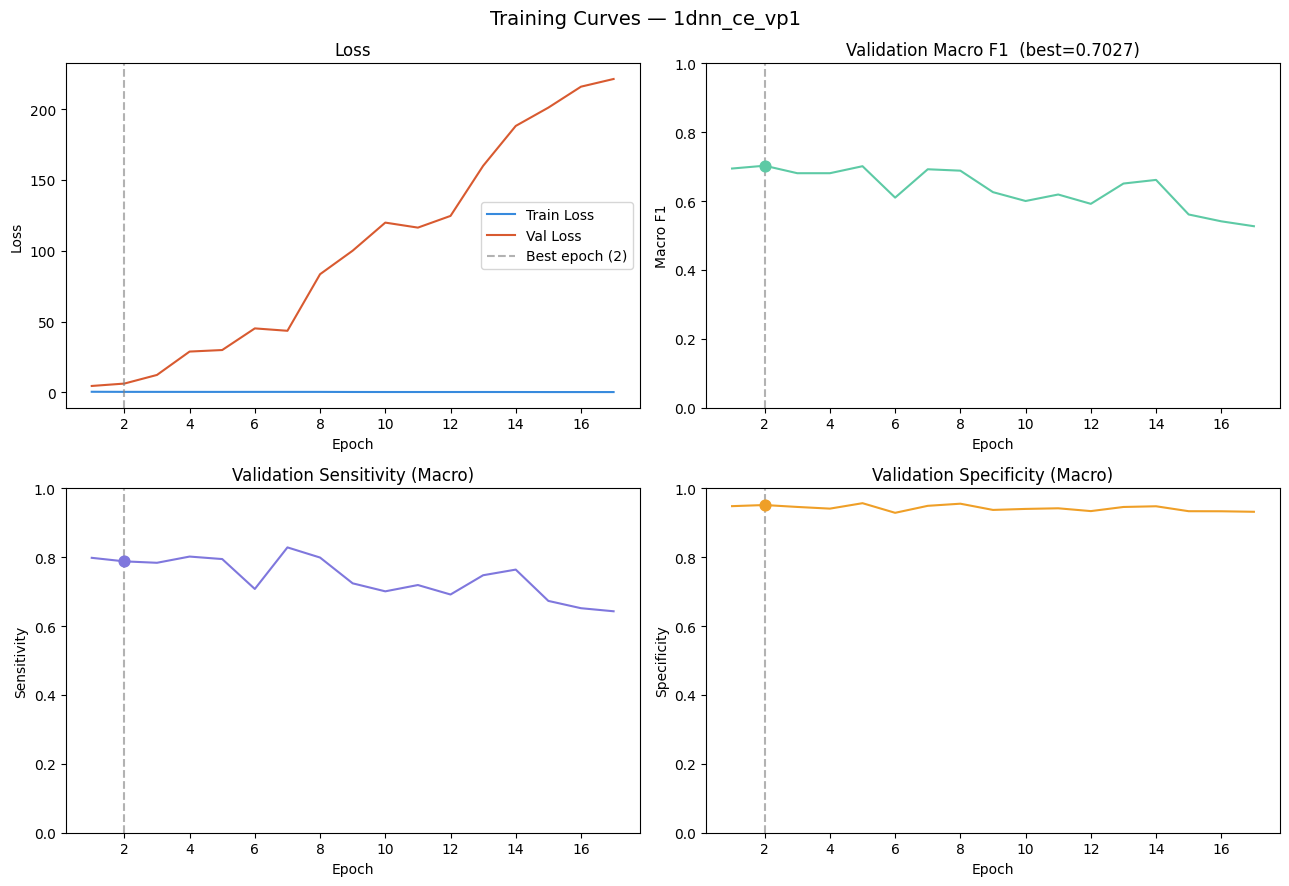

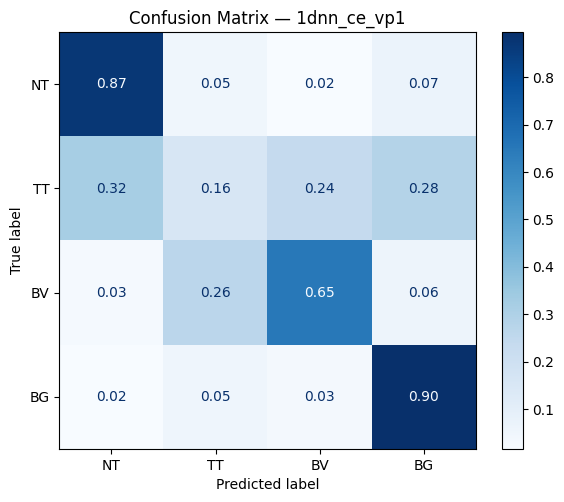

Loaded 10 test patients from history


/Users/joshua/Documents/Repositories/me/dylos-hsi/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)



═════════════════════════════════════════════════════════════════
  TEST RESULTS — 1dnn_ce_vp1
═════════════════════════════════════════════════════════════════
  Overall Accuracy (OA) : 0.8363
  Macro F1              : 0.5972

  Class                      Sensitivity  Specificity     Dice
  ────────────────────────────────────────────────────────────
  Normal Tissue (NT)              0.8701       0.9620   0.7576
  Tumour Tissue (TT)              0.1585       0.9332   0.1412
  Blood Vessel (BV)               0.6501       0.9570   0.5605
  Background (BG)                 0.8960       0.8728   0.9296
  ────────────────────────────────────────────────────────────
  Mean                            0.6437       0.9313   0.5972


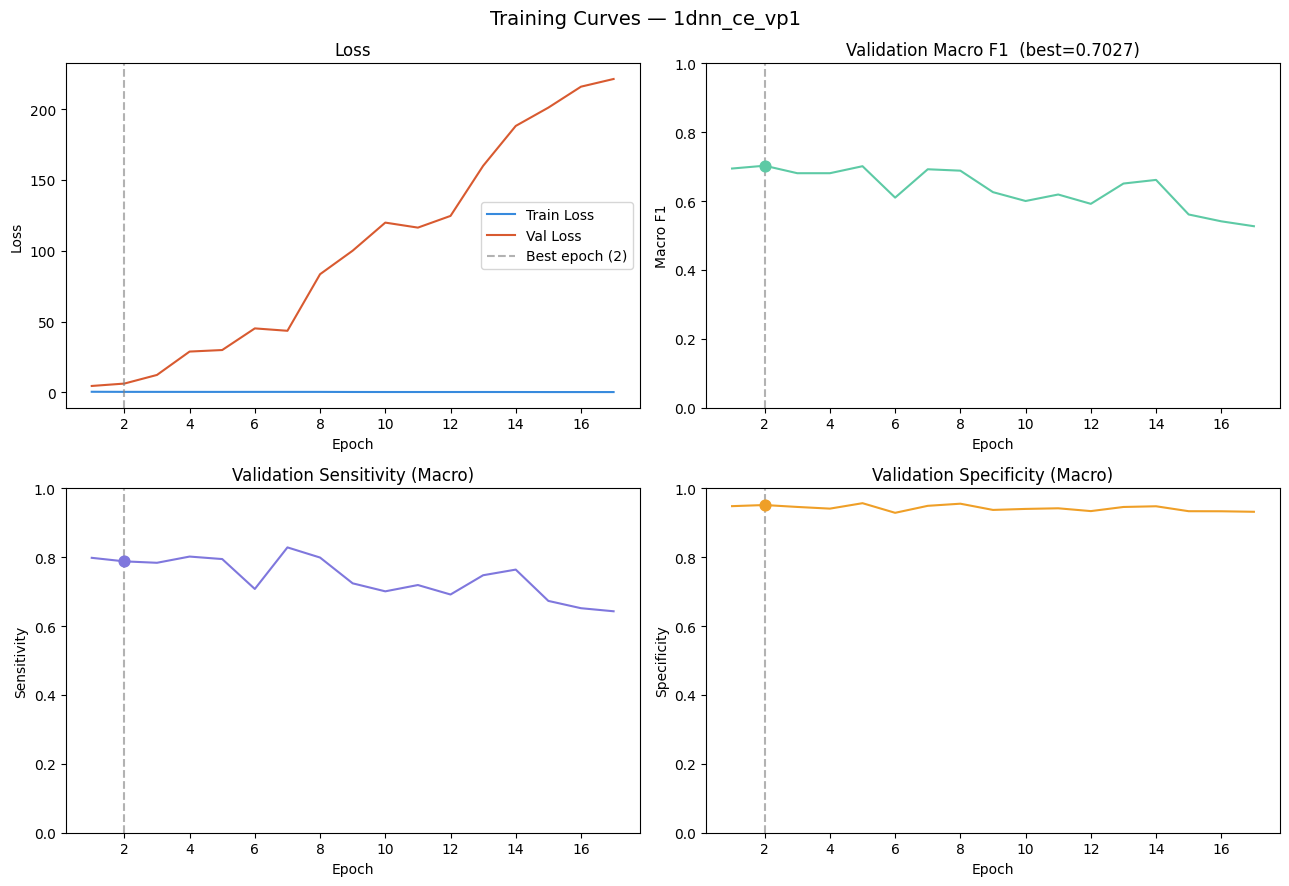

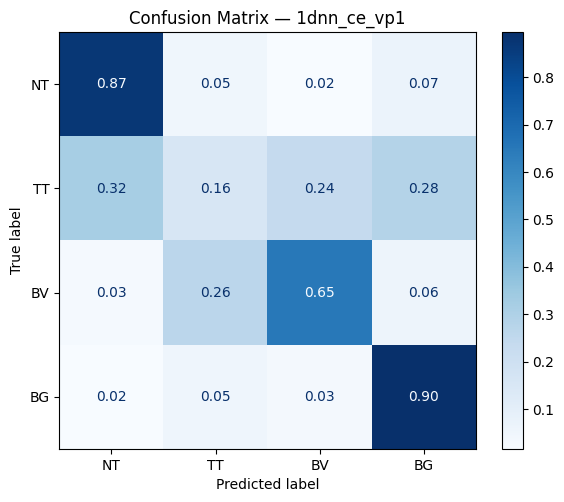

In [9]:
# Evaluate a single run
metrics = evaluate_run("1dnn_ce_vp1")

# Evaluate all VP1 runs
vp1_runs = sorted(Path(RESULTS_DIR).glob("*_vp1_history.npy"))
all_metrics = [evaluate_run(f.stem.replace('_history', '')) for f in vp1_runs]